## Problem Statement

The IPL is a fast-paced T20 league, and understanding match trends can be complex. This project analyzes **ball-by-ball data (2008-2023)** to explore **batting, bowling, match results, and venue impact** using **Exploratory Data Analysis (EDA)** to uncover key insights.

### **Dataset Info:**

**Match ID** : Unique identifier for each match.

**Date**: Date on which the match was played.

**Venue** : Name of the stadium where the match was played.

**Bat First** : Name of the team that batted first.

**Bat Second** : Name of the team that batted second.

**Innings** : Indicates the inning number (1 or 2) of the match.

**Over** : Specifies the over number within the inning.

**Ball** : Denotes the ball number within the over.

**Batter** : Name of the batsman facing the delivery.

**Non Striker** : Name of the non-striking batsman.

**Bowler** : Name of the bowler delivering the ball.

**Batter Runs** : Runs scored by the batsman on that specific delivery.

**Extra Runs** : Additional runs awarded due to extras like wides or no-balls.

**Runs From Ball** : Total runs scored from that delivery (batsman + extras).

**Ball Rebowled** : Indicator if the ball was rebowled (e.g., after a no-ball).

**Extra Type** : Type of extra run conceded (e.g., wide, no-ball, leg bye, bye).

**Wicket** : Indicates if a wicket fell on that delivery (1 for yes, 0 for no).

**Method** : Type of dismissal (e.g., bowled, caught, run out, etc.).

**Player Out** : Name of the dismissed player, if applicable.

**Innings Runs** : Total runs scored in the inning up to that ball.

**Innings Wickets** : Total number of wickets lost in the inning up to that ball.

**Target Score** : The target score set by the batting team (useful in chases).

**Runs to Get** : Runs required to win the match (only in chases).

**Balls Remaining** : Number of balls left in the innings.

**Winner** : Name of the team that won the match.

**Chased Successfully** : Indicator if the target was successfully chased (1 for yes, 0 for no).

**Total Batter Runs** : The total runs accumulated by the batter up until this delivery in the innings

**Total Non Striker Runs** : The total runs accumulated by the non-striker up until this delivery in the innings

**Batter Balls Faced** : The number of valid deliveries faced by the batter up until this delivery in the innings.

**Non Striker Balls Faced** : The number of valid deliveries faced by the non-striker up until this delivery in the innings.

**Player Out Runs** : The total runs scored by the dismissed player before getting out

**Player Out Balls Faced** : The number of valid deliveries faced by the dismissed player before getting out

**Bowler Runs Conceded** : Total runs conceded by the bowler in that ball.

**Valid Ball** : Indicates if the delivery was a valid ball (not wide/no-ball).

## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## **Load Data**

In [2]:
df = pd.read_csv('/content/ball_by_ball_ipl.csv', index_col=0)

## **Dataset Overview & Structure**

In [3]:
df.head()

,Match ID,Date,Venue,Bat First,Bat Second,Innings,Over,Ball,Batter,Non Striker,...,Winner,Chased Successfully,Total Batter Runs,Total Non Striker Runs,Batter Balls Faced,Non Striker Balls Faced,Player Out Runs,Player Out Balls Faced,Bowler Runs Conceded,Valid Ball
0,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,1,RD Gaikwad,DP Conway,...,Chennai Super Kings,0.0,4.0,0.0,1.0,0.0,NaN,NaN,4.0,1.0
1,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,2,RD Gaikwad,DP Conway,...,Chennai Super Kings,0.0,4.0,0.0,2.0,0.0,NaN,NaN,0.0,1.0
2,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,3,RD Gaikwad,DP Conway,...,Chennai Super Kings,0.0,4.0,0.0,3.0,0.0,NaN,NaN,0.0,1.0
3,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,4,RD Gaikwad,DP Conway,...,Chennai Super Kings,0.0,4.0,0.0,4.0,0.0,NaN,NaN,0.0,1.0
4,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,5,RD Gaikwad,DP Conway,...,Chennai Super Kings,0.0,5.0,0.0,5.0,0.0,NaN,NaN,1.0,1.0


In [4]:
df.tail()

,Match ID,Date,Venue,Bat First,Bat Second,Innings,Over,Ball,Batter,Non Striker,...,Winner,Chased Successfully,Total Batter Runs,Total Non Striker Runs,Batter Balls Faced,Non Striker Balls Faced,Player Out Runs,Player Out Balls Faced,Bowler Runs Conceded,Valid Ball
43450,1136594,2018-05-04,Holkar Cricket Stadium,Kings XI Punjab,Mumbai Indians,2,7,2,SA Yadav,Ishan Kishan,...,Mumbai Indians,1.0,28.0,0.0,23.0,2.0,NaN,NaN,0.0,1.0
43451,1136594,2018-05-04,Holkar Cricket Stadium,Kings XI Punjab,Mumbai Indians,2,7,3,SA Yadav,Ishan Kishan,...,Mumbai Indians,1.0,29.0,0.0,24.0,2.0,NaN,NaN,1.0,1.0
43452,1136594,2018-05-04,Holkar Cricket Stadium,Kings XI Punjab,Mumbai Indians,2,7,4,Ishan Kishan,SA Yadav,...,Mumbai Indians,1.0,0.0,29.0,3.0,24.0,NaN,NaN,0.0,1.0
43453,1136594,2018-05-04,Holkar Cricket Stadium,Kings XI Punjab,Mumbai Indians,2,7,5,Ishan Kishan,SA Yadav,...,Mumbai Indians,1.0,0.0,29.0,4.0,24.0,NaN,NaN,0.0,1.0
43454,1136594,2018-05-04,Holkar Cricket Stadium,Kings XI Punjab,Mumbai Indians,2,7,6,Ishan Kishan,SA Yadav,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape

(43455, 34)

#### **Identifying key columns and understanding data types**

In [6]:
df.columns

Index(['Match ID', 'Date', 'Venue', 'Bat First', 'Bat Second', 'Innings',
       'Over', 'Ball', 'Batter', 'Non Striker', 'Bowler', 'Batter Runs',
       'Extra Runs', 'Runs From Ball', 'Ball Rebowled', 'Extra Type', 'Wicket',
       'Method', 'Player Out', 'Innings Runs', 'Innings Wickets',
       'Target Score', 'Runs to Get', 'Balls Remaining', 'Winner',
       'Chased Successfully', 'Total Batter Runs', 'Total Non Striker Runs',
       'Batter Balls Faced', 'Non Striker Balls Faced', 'Player Out Runs',
       'Player Out Balls Faced', 'Bowler Runs Conceded', 'Valid Ball'],
      dtype='object')

In [7]:
df.dtypes

,0
Match ID,int64
Date,object
Venue,object
Bat First,object
Bat Second,object
Innings,int64
Over,int64
Ball,int64
Batter,object
Non Striker,object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43455 entries, 0 to 43454
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Match ID                 43455 non-null  int64  
 1   Date                     43455 non-null  object 
 2   Venue                    43455 non-null  object 
 3   Bat First                43455 non-null  object 
 4   Bat Second               43455 non-null  object 
 5   Innings                  43455 non-null  int64  
 6   Over                     43455 non-null  int64  
 7   Ball                     43455 non-null  int64  
 8   Batter                   43455 non-null  object 
 9   Non Striker              43455 non-null  object 
 10  Bowler                   43455 non-null  object 
 11  Batter Runs              43455 non-null  int64  
 12  Extra Runs               43455 non-null  int64  
 13  Runs From Ball           43455 non-null  int64  
 14  Ball Rebowled            43

## **Data Cleaning**

###**Standardizing Categorical Data**

Before moving to analysis, ensure data
consistency in categorical values:
Checking key categorical columns prevents errors in grouping, filtering, and aggregations



In [9]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_columns)

['Date', 'Venue', 'Bat First', 'Bat Second', 'Batter', 'Non Striker', 'Bowler', 'Extra Type', 'Method', 'Player Out', 'Winner']


#### **Cleaning Venue Names**

In [10]:
df['Venue'].unique()

array(['Eden Gardens', 'De Beers Diamond Oval', 'Sharjah Cricket Stadium',
       'Wankhede Stadium', 'Feroz Shah Kotla', 'Holkar Cricket Stadium',
       'Punjab Cricket Association IS Bindra Stadium',
       'Maharashtra Cricket Association Stadium',
       'MA Chidambaram Stadium', 'Dubai International Cricket Stadium',
       'Kingsmead', 'Dr DY Patil Sports Academy', 'SuperSport Park',
       'Sawai Mansingh Stadium',
       'Shaheed Veer Narayan Singh International Stadium',
       'M Chinnaswamy Stadium', 'Rajiv Gandhi International Stadium',
       'Brabourne Stadium', 'Sheikh Zayed Stadium',
       'M.Chinnaswamy Stadium', 'Punjab Cricket Association Stadium',
       'Narendra Modi Stadium', 'Arun Jaitley Stadium',
       'Barabati Stadium', 'Saurashtra Cricket Association Stadium',
       'Sardar Patel Stadium',
       'Himachal Pradesh Cricket Association Stadium', 'Nehru Stadium',
       'Green Park', 'Subrata Roy Sahara Stadium',
       'JSCA International Stadium Complex'

In [11]:
# Standardizing Venue Names
venue_map = {
    "M.Chinnaswamy Stadium": "M Chinnaswamy Stadium",
    "Sardar Patel Stadium": "Narendra Modi Stadium",
    "Punjab Cricket Association IS Bindra Stadium": "Punjab Cricket Association Stadium",
    "Feroz Shah Kotla": "Arun Jaitley Stadium",
    "Zayed Cricket Stadium": "Sheikh Zayed Stadium",
    "De Beers Diamond Oval": "Kimberley Oval",
    "Rajiv Gandhi International Stadium": "Uppal Stadium",
    "Dr Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium": "ACA-VDCA Stadium",
    "Shaheed Veer Narayan Singh International Stadium": "Raipur International Cricket Stadium",
    "JSCA International Stadium Complex": "Ranchi Stadium",
    "Barsapara Cricket Stadium": "Assam Cricket Association Stadium"
}

df["Venue"] = df["Venue"].replace(venue_map)

IPL teams wikipedia : https://en.wikipedia.org/wiki/Indian_Premier_League#:~:text=Timeline%20of%20teams

####**Cleaning Team Names**

In [12]:
df['Bat First'].unique()

array(['Chennai Super Kings', 'Rajasthan Royals', 'Mumbai Indians',
       'Delhi Daredevils', 'Royal Challengers Bangalore',
       'Delhi Capitals', 'Sunrisers Hyderabad', 'Rising Pune Supergiants',
       'Punjab Kings', 'Kings XI Punjab', 'Kochi Tuskers Kerala',
       'Pune Warriors', 'Deccan Chargers', 'Kolkata Knight Riders',
       'Gujarat Titans', 'Rising Pune Supergiant', 'Gujarat Lions',
       'Lucknow Super Giants'], dtype=object)

In [13]:
df['Bat Second'].unique()

array(['Kolkata Knight Riders', 'Chennai Super Kings', 'Delhi Capitals',
       'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Delhi Daredevils',
       'Mumbai Indians', 'Gujarat Titans', 'Rajasthan Royals',
       'Royal Challengers Bangalore', 'Deccan Chargers',
       'Sunrisers Hyderabad', 'Lucknow Super Giants', 'Punjab Kings',
       'Pune Warriors', 'Gujarat Lions', 'Rising Pune Supergiants'],
      dtype=object)

In [14]:
df['Winner'].unique()

array(['Chennai Super Kings', 'Delhi Capitals', 'Mumbai Indians',
       'Kings XI Punjab', 'Kochi Tuskers Kerala',
       'Royal Challengers Bangalore', 'Gujarat Titans', 'Punjab Kings',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Pune Warriors',
       'Rajasthan Royals', 'Sunrisers Hyderabad', 'Lucknow Super Giants',
       'Deccan Chargers', 'Gujarat Lions', 'Rising Pune Supergiants', nan],
      dtype=object)

In [15]:
team_name_map = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings"
}

df["Bat First"] = df["Bat First"].replace(team_name_map)
df["Bat Second"] = df["Bat Second"].replace(team_name_map)
df["Winner"] = df["Winner"].replace(team_name_map)

In [16]:
df['Bat First'].unique()

array(['Chennai Super Kings', 'Rajasthan Royals', 'Mumbai Indians',
       'Delhi Capitals', 'Royal Challengers Bangalore',
       'Sunrisers Hyderabad', 'Rising Pune Supergiants', 'Punjab Kings',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Deccan Chargers',
       'Kolkata Knight Riders', 'Gujarat Titans',
       'Rising Pune Supergiant', 'Gujarat Lions', 'Lucknow Super Giants'],
      dtype=object)

#### **Cleaning Player Names**

In [17]:
# Standardizing Player Names
df["Batter"] = df["Batter"].str.strip().str.title()
df["Non Striker"] = df["Non Striker"].str.strip().str.title()
df["Bowler"] = df["Bowler"].str.strip().str.title()
df["Player Out"] = df["Player Out"].str.strip().str.title()

### **Handling Missing & Duplicated Data**

#### **Identifying Missing values**

In [18]:
df.isna().sum()

,0
Match ID,0
Date,0
Venue,0
Bat First,0
Bat Second,0
Innings,0
Over,0
Ball,0
Batter,0
Non Striker,0




#### Observations:

* **Method** has **227,866 missing values** because it is only applicable when a wicket falls. It is **NaN for deliveries where no wicket fell**.  
* **Player Out** has **227,866 missing values** as it is recorded only when a wicket falls, making it **NaN for non-wicket deliveries**.  
* **Player Out Runs** has **227,866 missing values** because it is missing for deliveries where no player was out.  
* **Player Out Balls Faced** has **227,866 missing values** for the same reason—it is recorded only when a player gets out.  
* **Runs to Get** has **123,927 missing values** as it is **only relevant for the second innings**, making it **NaN for the first innings**.










In [19]:
# replacing missing values

df['Method'].fillna('Not Out', inplace=True)

df['Player Out'].fillna('None', inplace=True)
df['Player Out Runs'].fillna(0, inplace=True)

df['Player Out Balls Faced'].fillna(0, inplace=True)
df['Runs to Get'].fillna(0, inplace=True)

In [20]:
df.isnull().sum()

,0
Match ID,0
Date,0
Venue,0
Bat First,0
Bat Second,0
Innings,0
Over,0
Ball,0
Batter,0
Non Striker,0


Check for Duplicates

In [21]:
df.duplicated().sum()

np.int64(0)

No Duplicates found

###**Data Type Corrections**

**Match ID** should be converted from **int64** to **str** because it represents a categorical value, not a numerical one.

**Date** should be converted from **object** to **datetime64** since it is needed for time-series analysis.

**Ball Reboweled** should be converted from **int64** to **bool** by mapping 1 → True and 0 → False.

**Runs to Get** should be converted from **float64** to **int64** because runs are always whole numbers.

**Player Out Runs** should be converted from **object** to **int64** because it should be a numeric column.

**Player Out Balls** Faced should be converted from **float64** to **int64** because it should be an integer.

In [22]:
# Convert Match ID to string
df['Match ID'] = df['Match ID'].astype(str)

# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Convert Ball Rebowled to boolean
df['Ball Rebowled'] = df['Ball Rebowled'].astype(bool)

# Convert Runs to Get to integer
df['Runs to Get'] = df['Runs to Get'].astype(int)

# Convert Player Out Runs to integer
df['Player Out Runs'] = df['Player Out Runs'].astype(int)

# Convert Player Out Balls Faced to integer
df['Player Out Balls Faced'] = df['Player Out Balls Faced'].astype(int)

## **Feature Engineering**

In [23]:
df['Year'] = pd.to_datetime(df['Date']).dt.year

df['is_six'] = (df['Batter Runs'] == 6).astype(int)

In [24]:
df['Method'].unique()

array(['Not Out', 'bowled', 'caught', 'lbw', 'stumped', 'run out',
       'caught and bowled', 'retired hurt', 'hit wicket'], dtype=object)

In [25]:
valid_methods = ['bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']

df['bowler_wickets'] = df['Method'].isin(valid_methods).astype(int)


In [26]:
df['is_dot_ball'] = (
                      (df['Runs From Ball'] == 0)
                      & (df['Extra Runs'] == 0)
                      & (df['Valid Ball'] == 1)
                    ).astype(int)


##**EDA**

###**1.Who scored the highest total runs in each IPL season (Orange Cap winners)?**

In [27]:
batter_yearly_runs = df.groupby(['Year', 'Batter'])['Batter Runs'].sum().reset_index()

# Get the highest run-scorer for each year (Orange Cap winner)
orange_cap_winners = batter_yearly_runs.loc[batter_yearly_runs.groupby('Year')['Batter Runs'].idxmax()]

# Rename columns for clarity
orange_cap_winners = orange_cap_winners.rename(columns={'Batter Runs': 'Total Runs in Season'})

# Sort by year
orange_cap_winners = orange_cap_winners.sort_values('Year')

# Display the results
orange_cap_winners

,Year,Batter,Total Runs in Season
89,2008,Sr Watson,208
110,2009,Ac Gilchrist,118
231,2010,Rg Sharma,153
349,2011,V Sehwag,211
388,2012,G Gambhir,277
516,2013,Mek Hussey,327
606,2014,Lmp Simmons,142
670,2015,F Du Plessis,190
756,2016,Da Warner,266
857,2017,Hm Amla,169


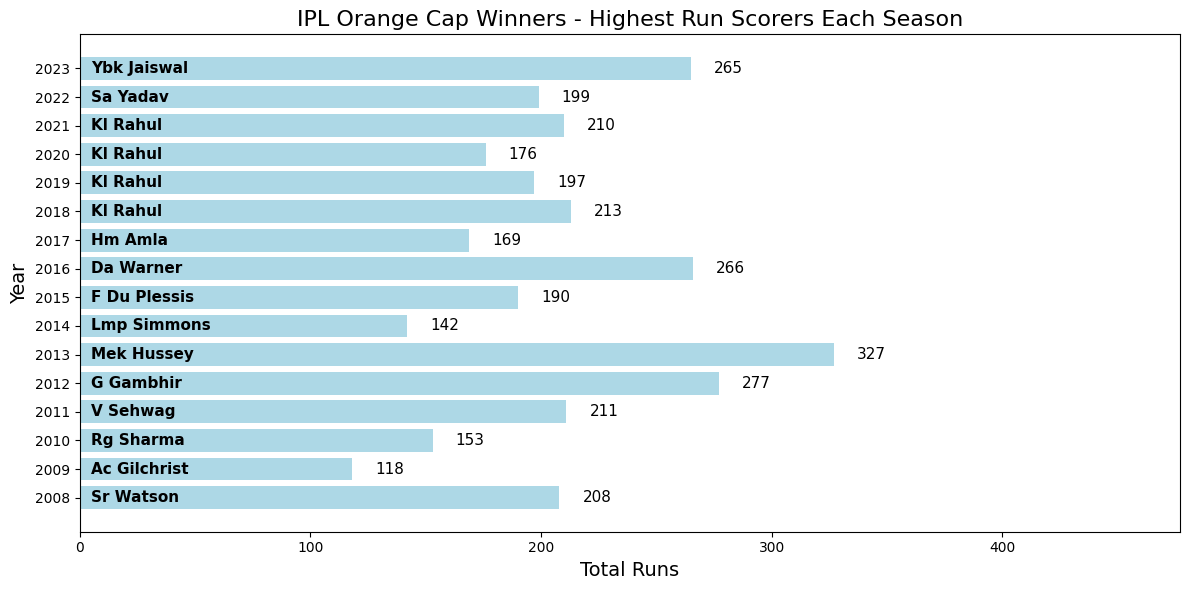

In [28]:
# Set the figure size
plt.figure(figsize=(12, 6))

# Create horizontal bar plot
plt.barh(orange_cap_winners['Year'].astype(str), orange_cap_winners['Total Runs in Season'], color='lightblue')

# Adding labels and title
plt.xlabel('Total Runs', fontsize=14)
plt.ylabel('Year', fontsize=14)
plt.title('IPL Orange Cap Winners - Highest Run Scorers Each Season', fontsize=16)

# Annotating batter names at the start and runs at the end of each bar
for i, (year, batter, runs) in enumerate(zip(orange_cap_winners['Year'],
                                             orange_cap_winners['Batter'],
                                             orange_cap_winners['Total Runs in Season'])):
    # Batter name at the start of the bar
    plt.text(5, i, batter, va='center', ha='left', fontsize=11, fontweight='bold', color='black')

    # Runs at the end of the bar
    plt.text(runs + 10, i, runs, va='center', ha='left', fontsize=11, color='black')

# Adjust plot limits for better spacing
plt.xlim(0, orange_cap_winners['Total Runs in Season'].max() + 150)

# Improve layout and appearance
plt.tight_layout()
plt.show()

###**2.Which batsman hitted the most sixes in each IPL season?**









In [29]:
# Step 1: Count total sixes for each batter per year
batter_sixes = df.groupby(['Year', 'Batter'])['is_six'].sum().reset_index()

# Step 2: Find the index of the batsman with the most sixes in each year using idxmax()
top_six_hitter_idx = batter_sixes.groupby('Year')['is_six'].idxmax()

# Step 3: Select the rows using the indices found
most_sixes_per_year = batter_sixes.loc[top_six_hitter_idx]

# Step 4: Rename the column for better clarity
most_sixes_per_year = most_sixes_per_year.rename(columns={'is_six': 'Total Sixes'})


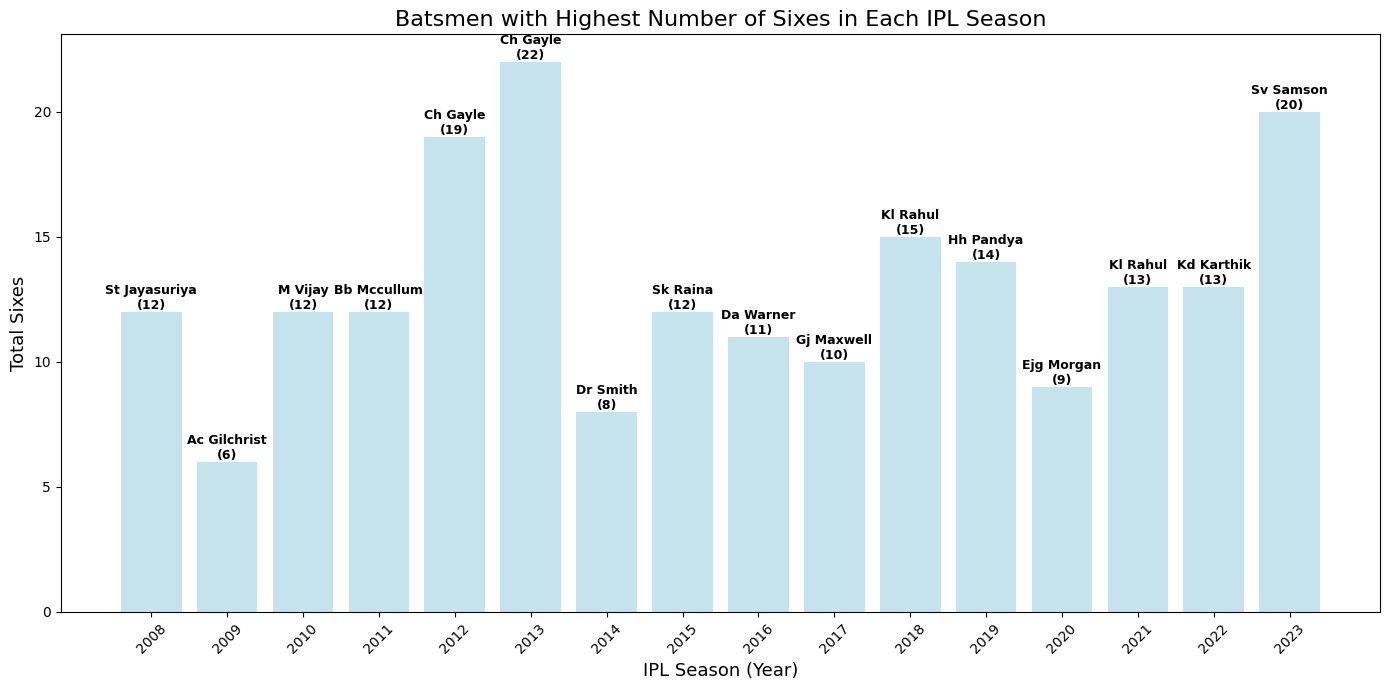

In [30]:
# Visualization (similar style to wickets visualization)
plt.figure(figsize=(14, 7))
bars = plt.bar(most_sixes_per_year['Year'].astype(str), most_sixes_per_year['Total Sixes'], color='lightblue', alpha=0.7)

# Annotate bars with batter names and total sixes
for bar, batter, sixes in zip(bars, most_sixes_per_year['Batter'], most_sixes_per_year['Total Sixes']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{batter}\n({sixes})',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Title and labels
plt.xlabel('IPL Season (Year)', fontsize=13)
plt.ylabel('Total Sixes', fontsize=13)
plt.title('Batsmen with Highest Number of Sixes in Each IPL Season', fontsize=16)
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()

###**3.Who took the highest wickets in each IPL season (Purple Cap winners)?**

In [31]:
# Count total wickets per bowler per year
wickets_per_year = df.groupby(['Year', 'Bowler'])['bowler_wickets'].sum().reset_index()

# Step 4: Find the top wicket-taker per year using idxmax()
top_wicket_taker_idx = wickets_per_year.groupby('Year')['bowler_wickets'].idxmax()

# Get the bowler with the most wickets per year using idxmax()
top_wicket_takers = wickets_per_year.loc[top_wicket_taker_idx]

# Rename column for clarity
top_wicket_takers = top_wicket_takers.rename(columns={'bowler_wickets': 'Total Wickets'})

top_wicket_takers

,Year,Bowler,Total Wickets
62,2008,Sr Watson,8
116,2009,Rp Singh,5
136,2010,A Mishra,5
257,2011,Rp Singh,10
321,2012,Kk Cooper,7
383,2013,Dj Bravo,11
453,2014,B Kumar,9
512,2015,A Nehra,12
578,2016,A Zampa,9
653,2017,Aj Tye,5


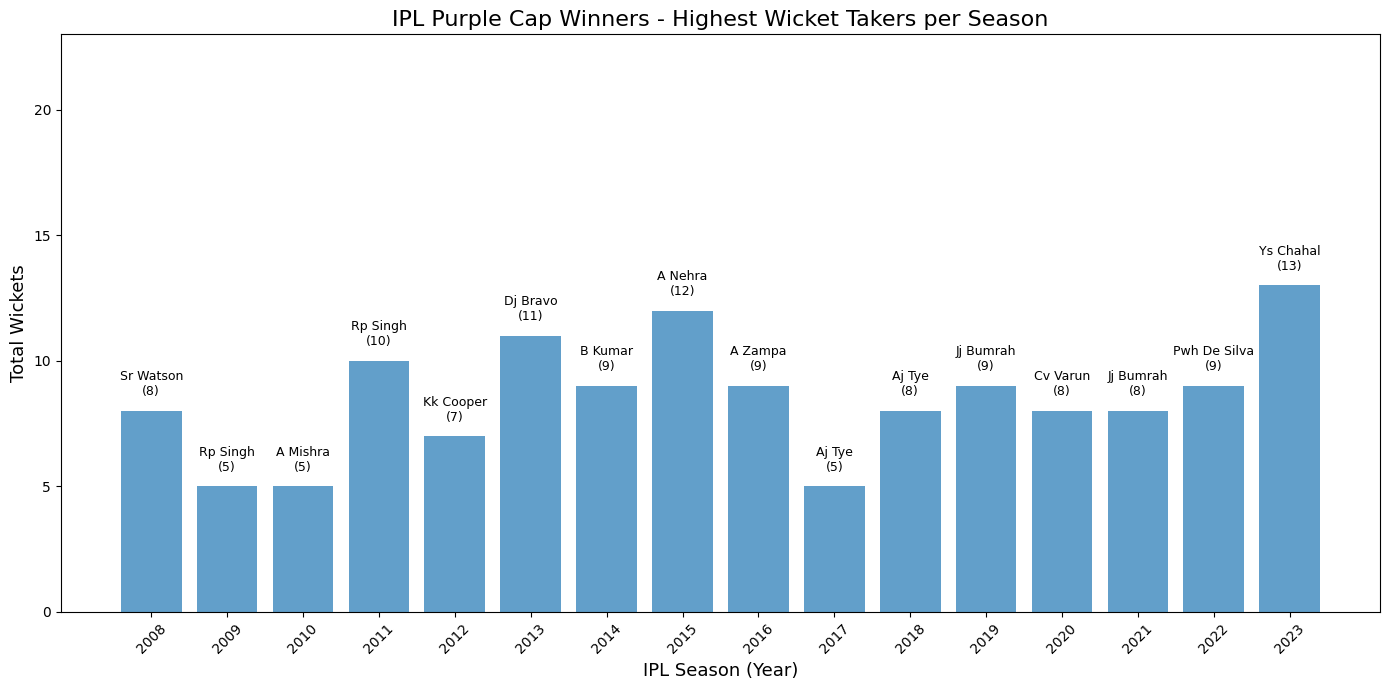

In [32]:
# Visualization
plt.figure(figsize=(14, 7))
bars = plt.bar(top_wicket_takers['Year'].astype(str), top_wicket_takers['Total Wickets'], alpha=0.7)

# Adding annotations for each bar
for bar, bowler, wickets in zip(bars, top_wicket_takers['Bowler'], top_wicket_takers['Total Wickets']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{bowler}\n({wickets})',
             ha='center', va='bottom', fontsize=9)

# Labels and title
plt.xlabel('IPL Season (Year)', fontsize=13)
plt.ylabel('Total Wickets', fontsize=13)
plt.title('IPL Purple Cap Winners - Highest Wicket Takers per Season', fontsize=16)
plt.xticks(rotation=45)
plt.ylim(0, top_wicket_takers['Total Wickets'].max() + 10)

plt.tight_layout()
plt.show()

### **4.Which bowler delivered the highest number of dot balls in each IPL season?**

In [33]:
# Step 1: Count total dot balls per bowler per year
dot_balls_per_bowler = df.groupby(['Year', 'Bowler'])['is_dot_ball'].sum().reset_index()

# Step 2 : Find the index of the bowler with the most dotballs in each year using idxmax()
top_dot_bowlers_idx = dot_balls_per_bowler.groupby('Year')['is_dot_ball'].idxmax()

# Step 4: Select the rows using the indices found
top_dot_bowlers = dot_balls_per_bowler.loc[top_dot_bowlers_idx]

# Step 5: Rename column for clarity
top_dot_bowlers = top_dot_bowlers.rename(columns={'is_dot_ball': 'Total Dot Balls'})


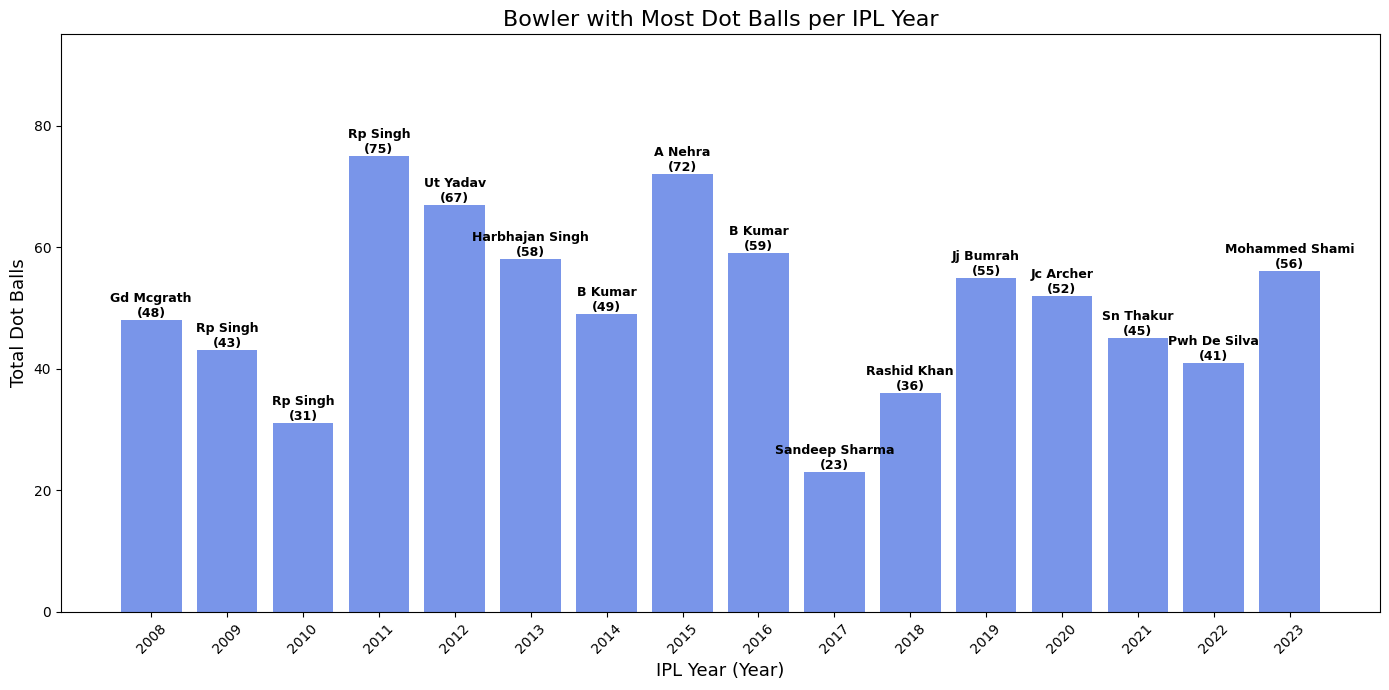

In [34]:

# Visualization
plt.figure(figsize=(14, 7))
bars = plt.bar(top_dot_bowlers['Year'].astype(str), top_dot_bowlers['Total Dot Balls'], color='royalblue', alpha=0.7)

# Adding annotations for each bar
for bar, bowler, dots in zip(bars, top_dot_bowlers['Bowler'], top_dot_bowlers['Total Dot Balls']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bowler}\n({dots})',
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

# Labels and title
plt.xlabel('IPL Year (Year)', fontsize=13)
plt.ylabel('Total Dot Balls', fontsize=13)
plt.title('Bowler with Most Dot Balls per IPL Year', fontsize=16)
plt.xticks(rotation=45)
plt.ylim(0, top_dot_bowlers['Total Dot Balls'].max() + 20)

# Improve layout
plt.tight_layout()
plt.show()

### **5.What was the highest target set in each IPL season?**

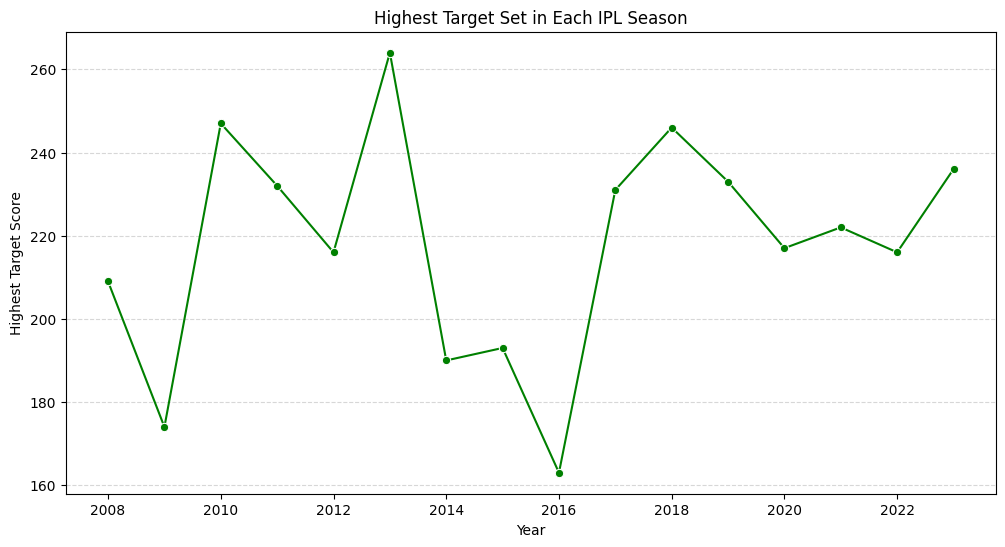

In [35]:
highest_target_per_season = df.groupby('Year')['Target Score'].max().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=highest_target_per_season, x='Year', y='Target Score', marker='o', color='green')
plt.xlabel('Year')
plt.ylabel('Highest Target Score')
plt.title('Highest Target Set in Each IPL Season')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


### **6.What was the lowest target set in each IPL season?**

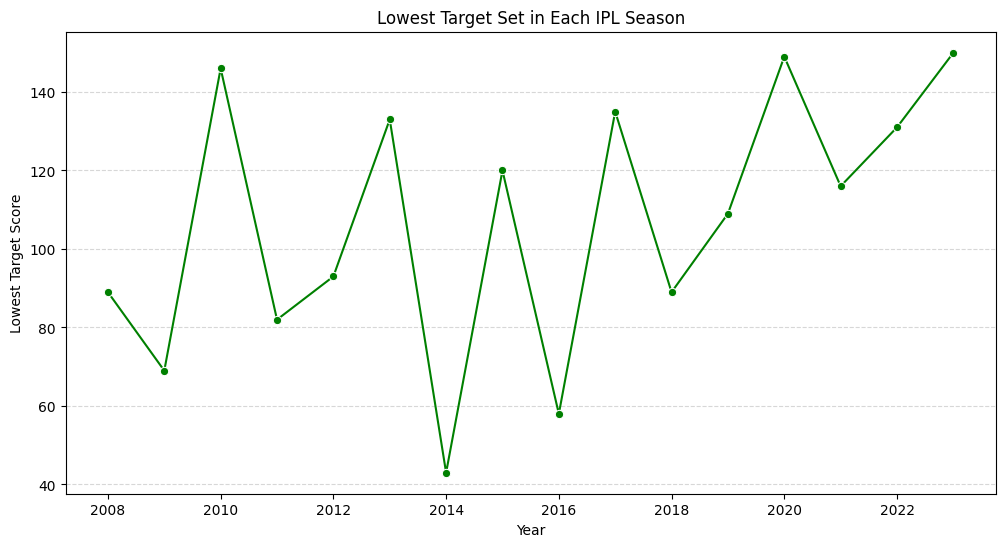

In [36]:
# Lowest Target Set in Each Season (Line Plot)
lowest_target_per_season = df.groupby('Year')['Target Score'].min().reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(data=lowest_target_per_season,
             x='Year',
             y='Target Score',
             marker='o',
             color='green')

plt.xlabel('Year')
plt.ylabel('Lowest Target Score')
plt.title('Lowest Target Set in Each IPL Season')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### **7.Count of IPL titles won by each team?**

In [37]:
# Step 1: Identify the last match of each year (final match)
final_matches = df.groupby('Year')['Match ID'].max().reset_index()

# Step 2: Find the winner of each final match
final_winners = df[df['Match ID'].isin(final_matches['Match ID'])][['Year', 'Winner']].drop_duplicates()

# Step 3: Count the number of IPL titles won by each team
winner_count = final_winners['Winner'].value_counts().reset_index()
winner_count.columns = ['Team', 'Titles Won']

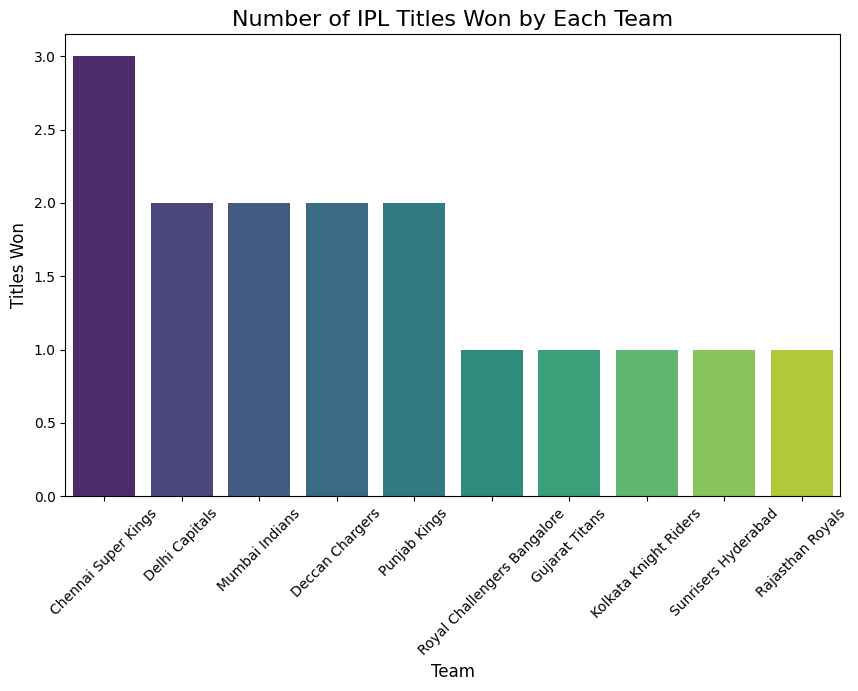

In [38]:
# Plot the bar graph using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Team', y='Titles Won', data=winner_count, palette='viridis')

# Add labels and title
plt.title('Number of IPL Titles Won by Each Team', fontsize=16)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Titles Won', fontsize=12)

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45)

# Show the plot
plt.show()

### **8.What is the overall win percentage for teams batting first compared to teams chasing across all seasons?**

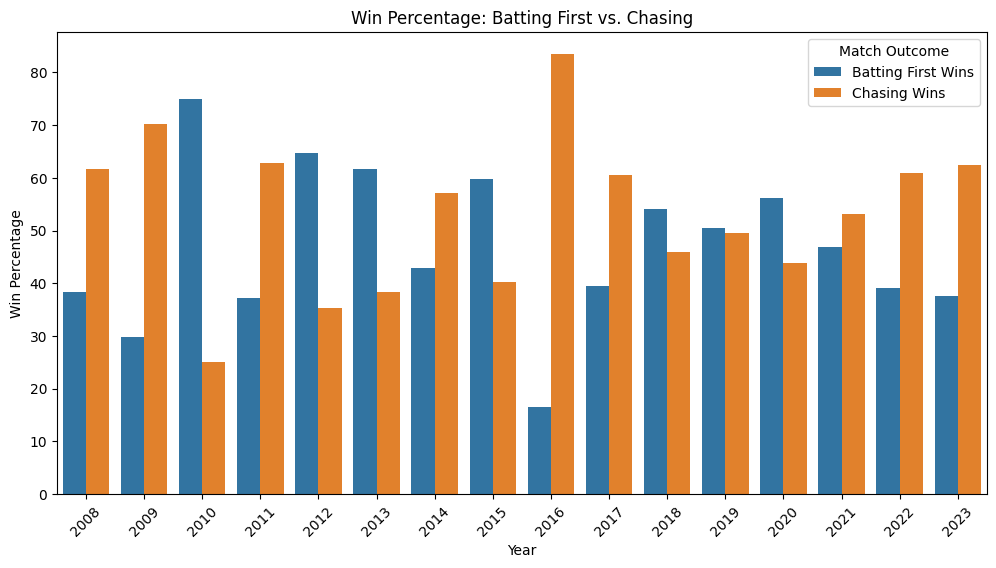

In [39]:
# Step 1: Count wins for teams batting first & chasing per year
win_counts = df.groupby(['Year', 'Chased Successfully']).size().reset_index(name='Win Count')

# Step 2: Convert win counts into percentages
total_wins_per_year = win_counts.groupby('Year')['Win Count'].transform('sum')
win_counts['Win Percentage'] = (win_counts['Win Count'] / total_wins_per_year) * 100
win_counts['Chased Successfully'] = win_counts['Chased Successfully'].replace({0: 'Batting First Wins', 1: 'Chasing Wins'})

# Step 3: Create a grouped bar chart with vibrant colors
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Win Percentage', hue='Chased Successfully', data=win_counts, palette='tab10')
plt.xlabel('Year')
plt.ylabel('Win Percentage')
plt.title('Win Percentage: Batting First vs. Chasing')
plt.legend(title="Match Outcome")
plt.xticks(rotation=45)
plt.show()

### **9. Which Player Scored the Fastest Fifty in Each Season?**

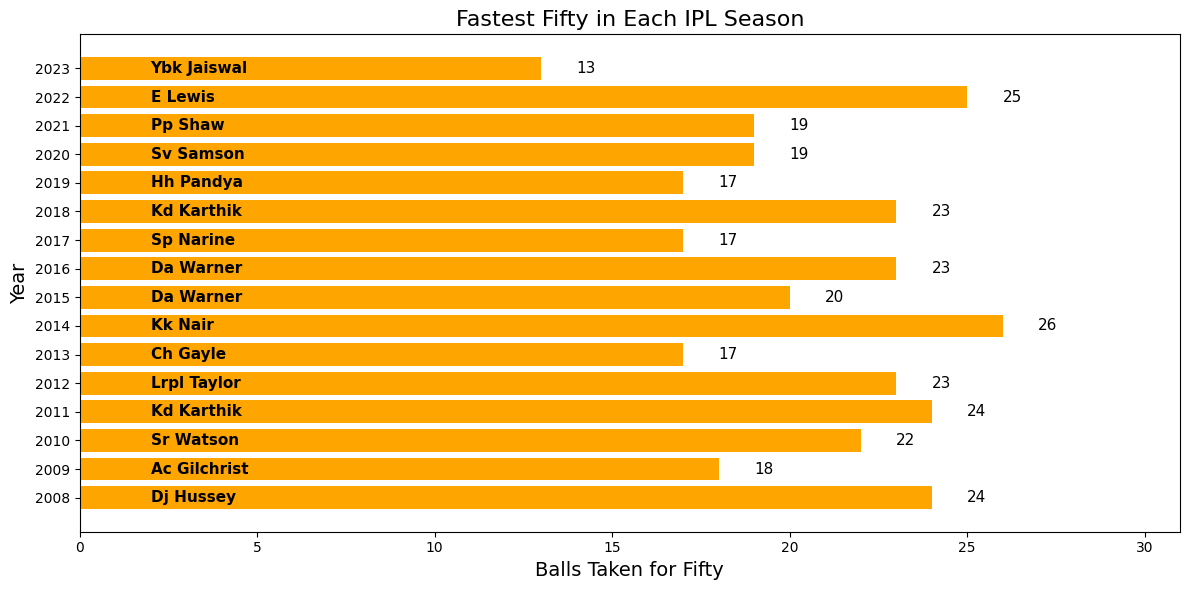

In [40]:
# Step 1: Calculate cumulative runs and balls faced for each batter in each match
df['Cumulative Runs'] = df.groupby(['Match ID', 'Batter'])['Batter Runs'].cumsum()
df['Balls Faced'] = df.groupby(['Match ID', 'Batter']).cumcount() + 1

# Step 2: Filter instances where the batter reaches 50 runs
fifties = df[df['Cumulative Runs'] >= 50]

# Step 3: Get the fastest fifty for each year using idxmin()
fastest_fifties = fifties.loc[fifties.groupby('Year')['Balls Faced'].idxmin(),
                              ['Year', 'Batter', 'Balls Faced']]

# Rename for clarity
fastest_fifties.columns = ['Year', 'Player', 'Balls Taken for Fifty']

# Convert 'Year' to string for visualization
fastest_fifties['Year'] = fastest_fifties['Year'].astype(str)

# Plot the fastest fifties
plt.figure(figsize=(12, 6))
plt.barh(fastest_fifties['Year'], fastest_fifties['Balls Taken for Fifty'], color='orange')

# Adding labels and title
plt.xlabel('Balls Taken for Fifty', fontsize=14)
plt.ylabel('Year', fontsize=14)
plt.title('Fastest Fifty in Each IPL Season', fontsize=16)

# Annotating player names at the start and balls taken at the end of each bar
for i, (year, player, balls) in enumerate(zip(fastest_fifties['Year'],
                                              fastest_fifties['Player'],
                                              fastest_fifties['Balls Taken for Fifty'])):
    # Player name at the start
    plt.text(2, i, player, va='center', ha='left', fontsize=11, fontweight='bold', color='black')

    # Balls taken at the end of the bar
    plt.text(balls + 1, i, balls, va='center', ha='left', fontsize=11, color='black')

# Adjust plot limits for better spacing
plt.xlim(0, fastest_fifties['Balls Taken for Fifty'].max() + 5)

# Improve layout and appearance
plt.tight_layout()
plt.show()

### **10.Which venues have hosted the most IPL matches?**

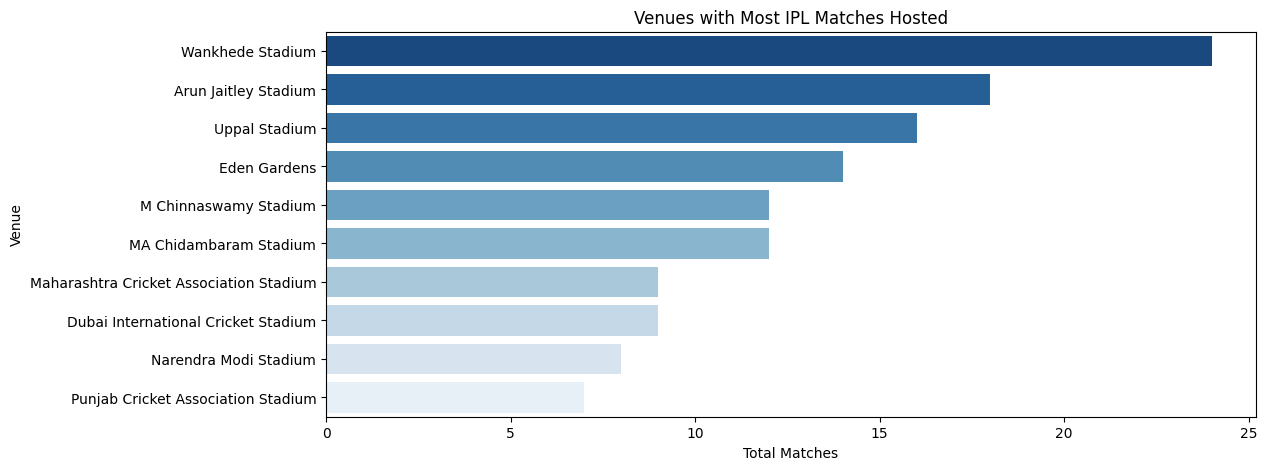

In [41]:
venue_match_counts = (
    df.groupby('Venue')['Match ID'].nunique()
    .reset_index()
    .rename(columns={'Match ID': 'Total Matches'})
    .sort_values('Total Matches', ascending=False)
)

plt.figure(figsize=(12, 5))
sns.barplot(data=venue_match_counts.head(10), x='Total Matches', y='Venue', palette='Blues_r')
plt.title("Venues with Most IPL Matches Hosted")
plt.xlabel("Total Matches")
plt.ylabel("Venue")
plt.show()